## Import

See `EDA_We_Re_edit_3_2_volume_fraction_full_corr.ipynb`

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('text', usetex=True )
plt.rc('font', family='Times New Roman', weight='normal', size=14)
# plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

from pathlib import Path
data_root = Path('../data')

import sys
sys.path.append('../')

import utils_functionality.velocity_calculation as vc
import utils_functionality.sedimentation_calculation as sc
from utils_functionality.model_analysis import extract_agg_features;

# from utils_functionality.models.modelling3_utils import _add_sedimentation_sign

sns.set_style('darkgrid')

plt.rcParams['figure.dpi'] = 200
plt.rcParams["font.family"] = "Times New Roman"
sns.set_theme(rc={"font.family": "Times New Roman"})

from collections import defaultdict

In [2]:
no_mixing_time = 60
density_liquid = 1000 # 800 ... 1200
viscosity_liquid = 10e-3 # 1e-3 ... 23e-3
particle_mean_diameter = 150e-6 # 40e-6 ... 300e-6
particle_liquid_density_ratio = 1.2 # 0.3 ... 1.9
init_volume_fraction = 0.06 # 0.04 ... 0.10
droplet_diameter = 0.003 # 1 mm ... 4 mm

sedimentation_params = {
    'time': no_mixing_time,
    'density_liquid': density_liquid, # 800 ... 1200
    'viscosity_liquid': viscosity_liquid, # 1e-3 ... 23e-3
    'particle_mean_diameter': particle_mean_diameter, # 40e-6 ... 300e-6
    'particle_liquid_density_ratio': particle_liquid_density_ratio, # 0.3 ... 1.9
    'init_volume_fraction': init_volume_fraction, # 0.04 ... 0.10
    'droplet_diameter': droplet_diameter # 1 mm ... 4 mm
}

def iterate_params(
    iteration_param: dict[str, list],
    sedimentation_params:dict,
)->pd.DataFrame:
    results = defaultdict(list)
    
    for key, values in iteration_param.items():
        for value in values:
            updated_sedimentation_params = {
                **sedimentation_params,
                **{key: value}
            }
            (
                phi_drop_term, v_term, sedimentation_Re
            ) = sc.get_drop_volume_fraction(
                **updated_sedimentation_params
            )
            results[key].append(value)
            results['v_term'].append(v_term)
            results['phi_drop_term'].append(phi_drop_term)
            results['sedimentation_Re'].append(sedimentation_Re)
    
    return pd.DataFrame(results)


def plot_dependency(
    independent_feature,
    independent_values,
    dependent_feature,
    title:str=None,
    ax=None,
):
    results = iterate_params(
        iteration_param={independent_feature: independent_values},
        sedimentation_params=sedimentation_params,
    )
    df = pd.DataFrame(results)

    if ax is None:
        fig, ax = plt.subplots(1,1, dpi=200)
    sns.lineplot(
        data=df,
        x=independent_feature,
        y=dependent_feature,
        ax=ax,
    );
    ax.set_title(title) 

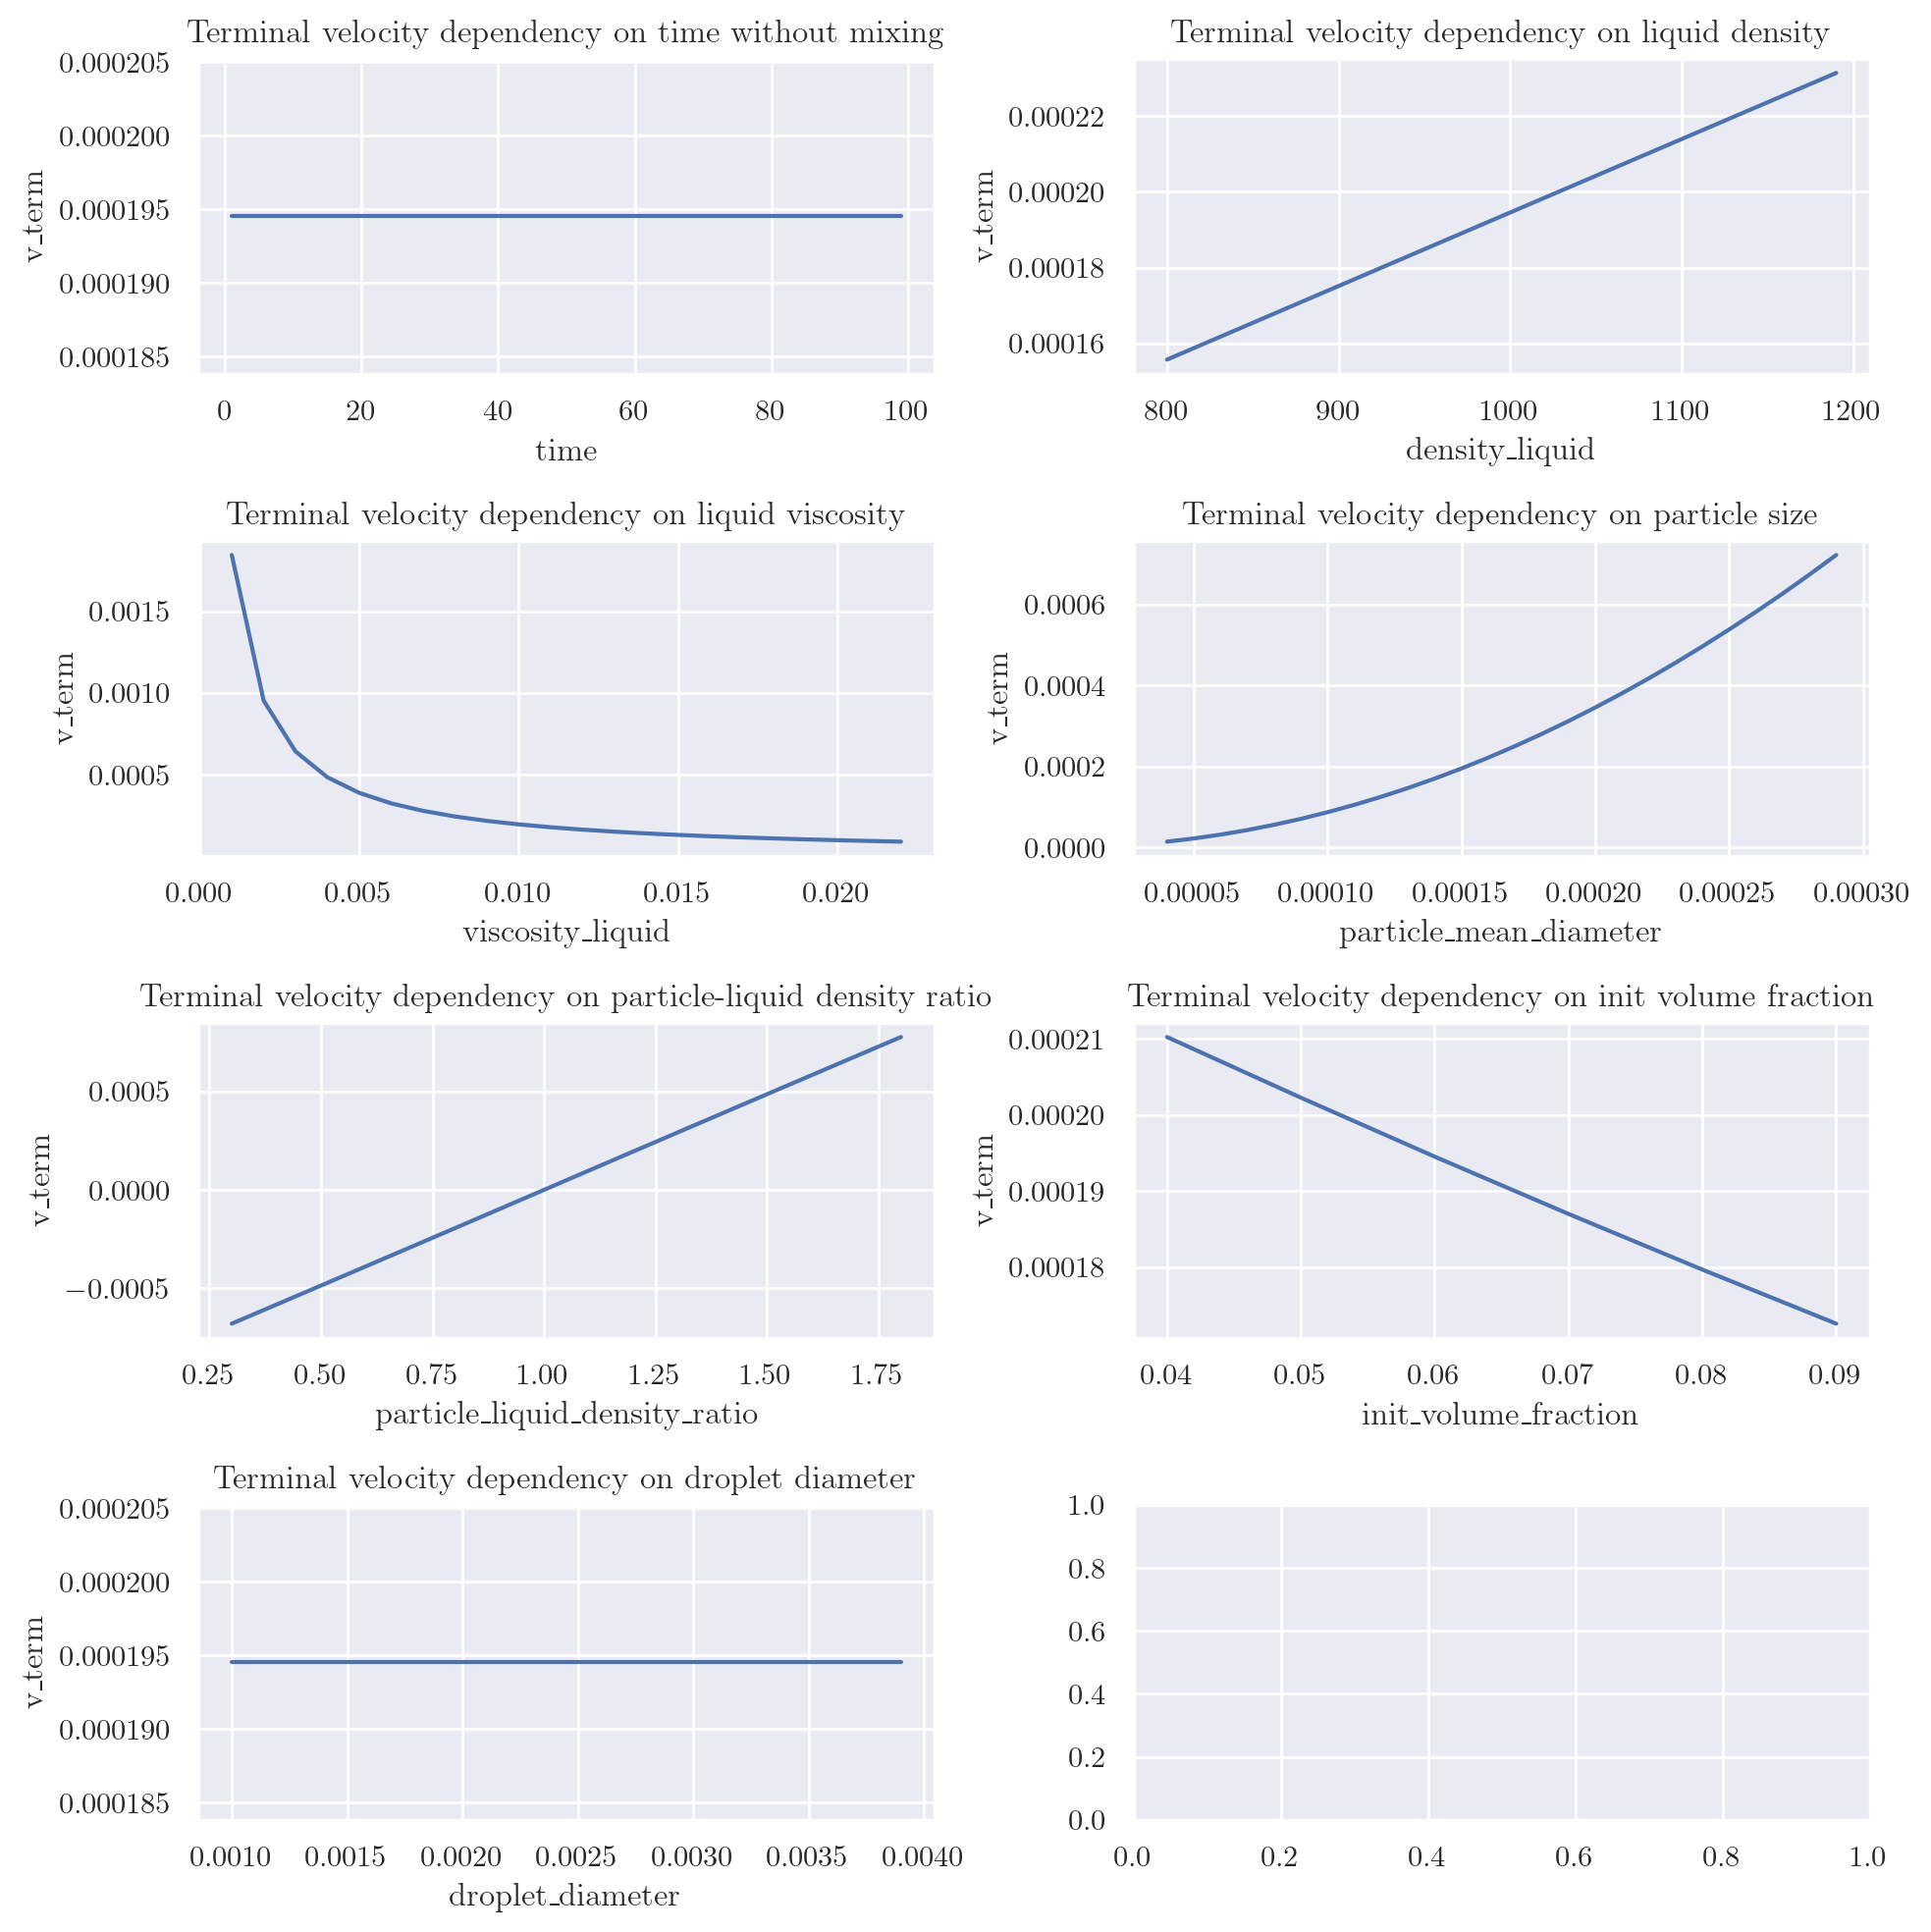

In [3]:
independent_params = {
    'time': list(np.arange(1,100)),
    'density_liquid': list(np.arange(800, 1200, 10)),
    'viscosity_liquid': list(np.arange(1e-3, 23e-3, 1e-3)),
    'particle_mean_diameter': list(np.arange(40e-6, 300e-6, 10e-6)),
    'particle_liquid_density_ratio': list(np.arange(0.3, 1.9, 0.1)),
    'init_volume_fraction': list(np.arange(0.04, 0.10, 0.01)),
    'droplet_diameter': list(np.arange(0.001, 0.004, 1e-4))
}

titles = [
    'Terminal velocity dependency on time without mixing',
    'Terminal velocity dependency on liquid density',
    'Terminal velocity dependency on liquid viscosity',
    'Terminal velocity dependency on particle size',
    'Terminal velocity dependency on particle-liquid density ratio',
    'Terminal velocity dependency on init volume fraction',
    'Terminal velocity dependency on droplet diameter',
]

fig, axs = plt.subplots(4, 2, dpi=200, figsize=(10, 10))

for ax, independent_feature, independent_values, title in zip(
    axs.flatten(),
    list(independent_params.keys()),
    list(independent_params.values()),
    titles
):
    dependent_feature = 'v_term'
    plot_dependency(
        independent_feature=independent_feature,
        independent_values=independent_values,
        dependent_feature=dependent_feature,
        title=title,
        ax=ax,
    )

fig.tight_layout()